# Irreducible mass of Black Holes

Rotating BH have a irreducible mass wich is function of the gravitational mass due to Penrose process. The relation between the two can be written as:
$$
M_{irr} = M f(\chi) = M \sqrt{\frac{1 + \sqrt{1 - \chi^2 }}{2}}
$$
We procede normalizing at 1 the true value.

In [124]:
mu = 1.0
sigma = 0.2

In [125]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import astropy.visualization.hist as hist


(0.0, 2.0)

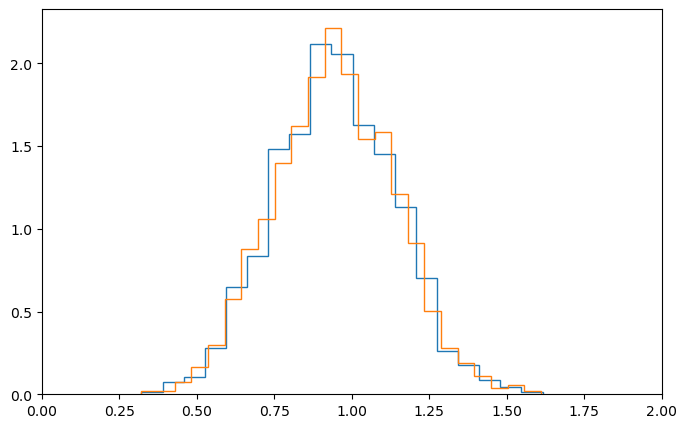

In [126]:
nsample = 1000

chi = np.random.uniform(0,1, nsample)
M = np.random.normal(mu, sigma, nsample)

Mirr = np.zeros(nsample)
for i in range(nsample): Mirr[i] = M[i]*np.sqrt(0.5*(1+np.sqrt(1-chi[i]**2)))

plt.figure(figsize=(8, 5))
hist(Mirr, bins="scott", histtype="step",density=True)
hist(Mirr, bins="freedman", histtype="step",density=True)
plt.xlim(0,2)

In [127]:
from sklearn.neighbors import KernelDensity

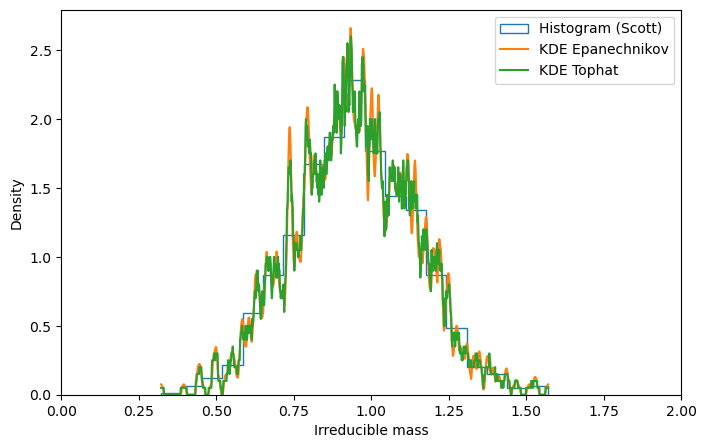

In [128]:
kde_epanechnikov = KernelDensity(bandwidth=0.01, kernel="epanechnikov")
kde_tophat = KernelDensity(bandwidth=0.01, kernel="tophat")

kde_epanechnikov.fit(Mirr[:, np.newaxis])
kde_tophat.fit(Mirr[:, np.newaxis])

xgrid = np.linspace(Mirr.min(), Mirr.max(), 1000)

pdf_epanechnikov = np.exp(kde_epanechnikov.score_samples(xgrid[:, np.newaxis]))
pdf_tophat = np.exp(kde_tophat.score_samples(xgrid[:, np.newaxis]))

plt.figure(figsize=(8, 5))
plt.hist(Mirr, bins="scott", histtype="step",density=True, label="Histogram (Scott)")
plt.plot(xgrid, pdf_epanechnikov, "-", label="KDE Epanechnikov")
plt.plot(xgrid, pdf_tophat, "-", label="KDE Tophat")
plt.xlim(0,2)
plt.xlabel("Irreducible mass")
plt.ylabel("Density")
plt.legend()
plt.show()

In [129]:
f_chi = np.sqrt(0.5*(1+np.sqrt(1-chi**2)))

print('KS test for Epanechnikov kernel: ', stats.kstest(f_chi,pdf_epanechnikov)[0])
print('KS test for Tophat kernel: ', stats.kstest(f_chi, pdf_tophat)[0])

KS test for Epanechnikov kernel:  0.529
KS test for Tophat kernel:  0.542


/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:394: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  return hypotest_fun_in(*args, **kwds)


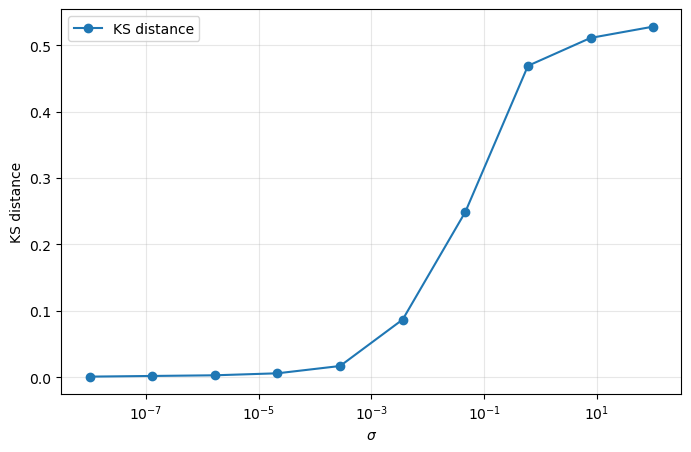

In [ ]:
results_epanechnikov, results_tophat = [], []

sigma_n = np.logspace(2, 2 - N, N)

# Chosen obtimal bandwidth for the KDEs
kde_epanechnikov = KernelDensity(bandwidth=0.1, kernel="epanechnikov")
kde_tophat = KernelDensity(bandwidth=0.1, kernel="tophat")

chi = np.random.uniform(0, 1, nsample)
f_chi = np.sqrt(0.5 * (1 + np.sqrt(1 - chi**2)))


for sigma in sigma_n:
    M = np.random.normal(mu, sigma, nsample)
    Mirr = M * f_chi

    ks_stat_e = stats.kstest(Mirr, f_chi)[0]
    ks_stat_t = stats.kstest(Mirr, f_chi)[0] # In questo caso il KDE non serve

    results_epanechnikov.append(ks_stat_e)
    results_tophat.append(ks_stat_t)

plt.figure(figsize=(8, 5))
plt.plot(sigma_n, results_epanechnikov, marker='o', label="KS distance")
plt.xlabel("$\sigma$")
plt.ylabel("KS distance")
plt.xscale("log")
plt.grid(alpha=0.3)
plt.legend()
plt.show()